# Module 1.8b — Burgers' Equation with a Gaussian Pulse

This notebook demonstrates all key concepts of Burgers' equation using a **Gaussian pulse** as the initial condition — similar to how we studied advection and diffusion in earlier modules.

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}$$

## Why a Gaussian Pulse?

| Feature | Sine wave (module 1.8) | Gaussian pulse (this notebook) |
|---------|------------------------|-------------------------------|
| Initial shape | Smooth oscillation | Isolated bump |
| Shock location | Fixed at $x = \pi$ | Forms on the **right flank** of the pulse |
| Physical analogy | Wave in a periodic channel | Pressure pulse, traffic jam, flood wave |
| Easier to see | Periodic shock formation | Asymmetric steepening of one side |

## What You Will See

1. **Setup** — Gaussian pulse and grid
2. **Nonlinearity visualized** — why the right flank steepens and the left flank flattens
3. **Inviscid Burgers** — shock forms on the right side of the pulse
4. **Viscous Burgers** — diffusion smooths the shock; compare different $\nu$
5. **Convection vs Diffusion balance** — watch the two forces compete
6. **What breaks** — central differencing for the convection term (always unstable)

## 1. Setup — Grid and Gaussian Pulse

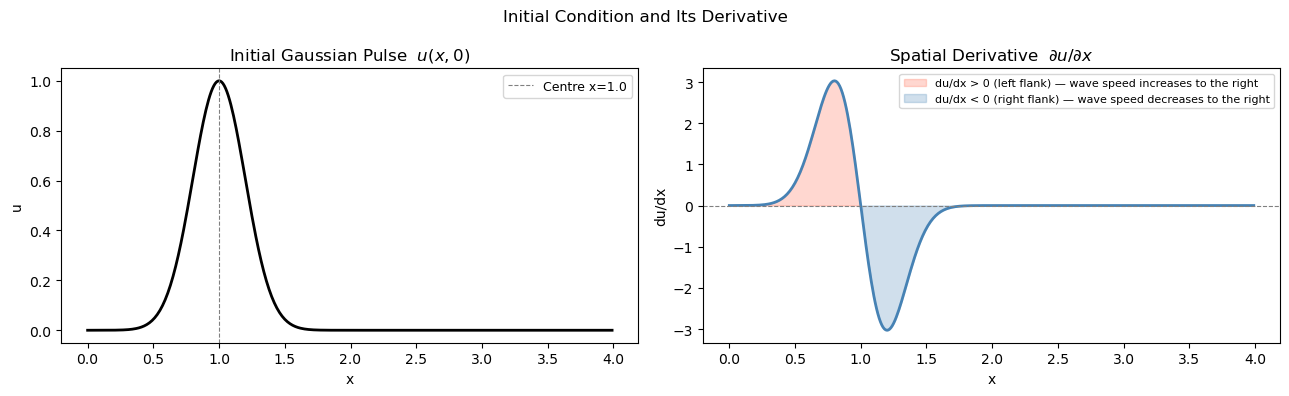

Grid: N=400, dx=0.0100
Pulse: centre=1.0, amplitude=1.0, sigma=0.2
Max |du0/dx| = 3.0301  at  x ≈ 0.800


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Grid ───────────────────────────────────────────────────────────────────────
L  = 4.0          # domain [0, 4]  — wide enough to see asymmetric steepening
N  = 400          # fine grid
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)

# ── Gaussian pulse: centred at x0, height A, width sigma ──────────────────────
x0    = 1.0    # centre — left of domain so we see rightward propagation
sigma = 0.2    # width
A     = 1.0    # amplitude (also the max wave speed for this pulse)

def gaussian(x_arr, centre=x0, amplitude=A, width=sigma):
    return amplitude * np.exp(-((x_arr - centre)**2) / (2 * width**2))

u0 = gaussian(x)

# ── Also compute the spatial derivative du0/dx — useful later ─────────────────
du0dx = np.zeros(N)
du0dx[1:-1] = (u0[2:] - u0[:-2]) / (2 * dx)   # central difference

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, u0, "k-", lw=2)
axes[0].axvline(x0, color="gray", ls="--", lw=0.8, label=f"Centre x={x0}")
axes[0].set_title("Initial Gaussian Pulse  $u(x,0)$", fontsize=12)
axes[0].set_xlabel("x"); axes[0].set_ylabel("u")
axes[0].legend(fontsize=9)

axes[1].plot(x, du0dx, "steelblue", lw=2)
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].fill_between(x, du0dx, where=(du0dx > 0), alpha=0.25, color="tomato",
                     label="du/dx > 0 (left flank) — wave speed increases to the right")
axes[1].fill_between(x, du0dx, where=(du0dx < 0), alpha=0.25, color="steelblue",
                     label="du/dx < 0 (right flank) — wave speed decreases to the right")
axes[1].set_title("Spatial Derivative  $\\partial u/\\partial x$", fontsize=12)
axes[1].set_xlabel("x"); axes[1].set_ylabel("du/dx")
axes[1].legend(fontsize=8)

plt.suptitle("Initial Condition and Its Derivative", fontsize=12)
plt.tight_layout(); plt.show()

print(f"Grid: N={N}, dx={dx:.4f}")
print(f"Pulse: centre={x0}, amplitude={A}, sigma={sigma}")
print(f"Max |du0/dx| = {np.max(np.abs(du0dx)):.4f}  at  x ≈ {x[np.argmax(np.abs(du0dx))]:.3f}")

## 2. Why the Right Flank Steepens — The Nonlinearity Explained

In the advection equation $\partial u/\partial t + c\,\partial u/\partial x = 0$, every point travels at the **same speed** $c$ — the shape is preserved.

In Burgers' equation, every point travels at its **own speed** $u_i$:

| Location | $u$ value | Wave speed | Direction of change |
|----------|-----------|-----------|---------------------|
| Peak | $u = A$ (maximum) | Fast | Overtakes the right side |
| Right flank | $u$ decreasing | Slow | Gets overtaken by the peak |
| Left flank | $u$ increasing from left | Medium | Gets stretched away from peak |

**Result:** The right flank steepens (fast catches up to slow) → **shock**. The left flank broadens (fast moves away from slow) → **rarefaction**.

This is exactly your car analogy — but now **every point is a car** with speed equal to its own velocity $u$.

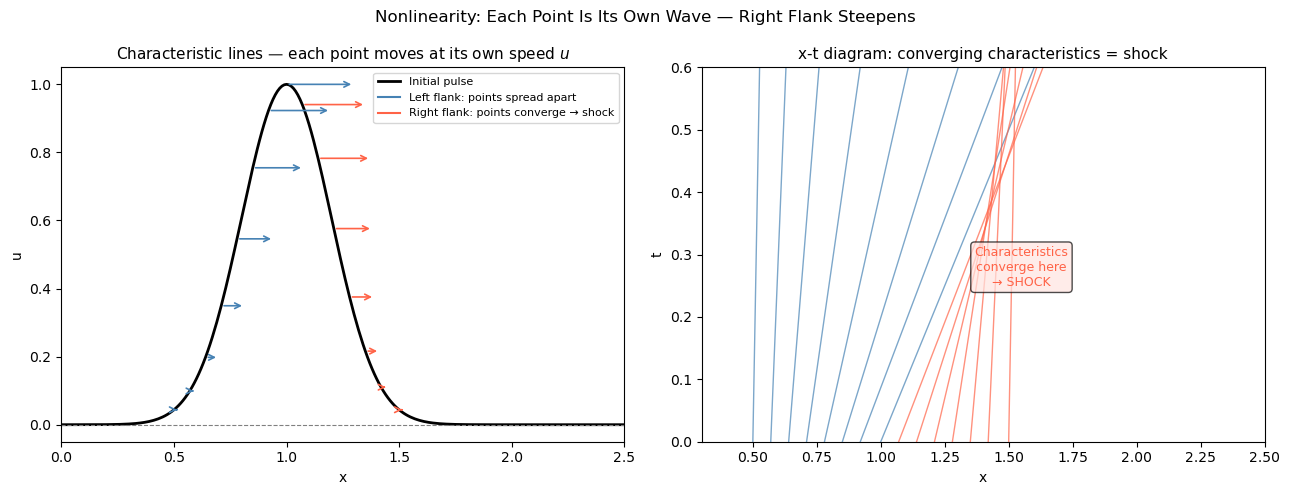

Left flank (blue arrows): points spread apart → broadens (rarefaction)
Right flank (red arrows): points converge    → steepens → shock


In [2]:
# ── Visualize characteristic lines: each point moves at speed u(x,0) ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: draw characteristic trajectories for selected points
ax = axes[0]
ax.plot(x, u0, "k-", lw=2, label="Initial pulse")
ax.axhline(0, color="gray", lw=0.8, ls="--")

# Sample 15 points across the pulse; draw arrows showing where they'll go
sample_idx = np.linspace(int(0.5/dx), int(1.5/dx), 15, dtype=int)
t_arrow    = 0.3   # how far ahead to project

for idx in sample_idx:
    xi   = x[idx]
    ui   = u0[idx]
    x_new = xi + ui * t_arrow   # characteristic: x(t) = x0 + u0 * t
    ax.annotate("", xy=(x_new, ui), xytext=(xi, ui),
                arrowprops=dict(arrowstyle="->",
                                color="tomato" if xi > x0 else "steelblue",
                                lw=1.2))

ax.set_title("Characteristic lines — each point moves at its own speed $u$", fontsize=11)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.set_xlim(0, 2.5)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color="k",         lw=2,   label="Initial pulse"),
    Line2D([0],[0], color="steelblue", lw=1.5, label="Left flank: points spread apart"),
    Line2D([0],[0], color="tomato",    lw=1.5, label="Right flank: points converge → shock"),
], fontsize=8)

# Right: x-t diagram showing characteristic convergence
ax2 = axes[1]
t_max = 0.6
for idx in sample_idx:
    xi = x[idx]; ui = u0[idx]
    t_range = np.linspace(0, t_max, 50)
    x_char  = xi + ui * t_range
    color   = "tomato" if xi > x0 else "steelblue"
    ax2.plot(x_char, t_range, color=color, lw=1, alpha=0.7)

ax2.set_title("x-t diagram: converging characteristics = shock", fontsize=11)
ax2.set_xlabel("x"); ax2.set_ylabel("t")
ax2.set_xlim(0.3, 2.5); ax2.set_ylim(0, t_max)
ax2.text(1.55, 0.25, "Characteristics\nconverge here\n→ SHOCK", fontsize=9,
         color="tomato", ha="center",
         bbox=dict(boxstyle="round", facecolor="mistyrose", alpha=0.7))

plt.suptitle("Nonlinearity: Each Point Is Its Own Wave — Right Flank Steepens", fontsize=12)
plt.tight_layout(); plt.show()

print("Left flank (blue arrows): points spread apart → broadens (rarefaction)")
print("Right flank (red arrows): points converge    → steepens → shock")

## 3. Inviscid Burgers ($\nu = 0$) — Shock Formation on Right Flank

With no viscosity, the equation is $\partial u/\partial t + u\,\partial u/\partial x = 0$.

The discretization uses **general upwind** for the nonlinear term:

$$u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x}\left[\max(u_i^n,0)(u_i^n - u_{i-1}^n) + \min(u_i^n,0)(u_{i+1}^n - u_i^n)\right]$$

**Shock formation time** for a Gaussian: the steepest descent is the right flank.
At $x = x_0 + \sigma$ (one sigma to the right), $du_0/dx \approx -A/(\sigma e^{1/2})$.
The shock forms at:

$$t_s = \frac{-1}{\min(du_0/dx)} \approx \frac{\sigma\,e^{1/2}}{A} \approx \frac{0.2 \times 1.65}{1.0} \approx 0.33$$

Theoretical shock time: t_s = 0.3300


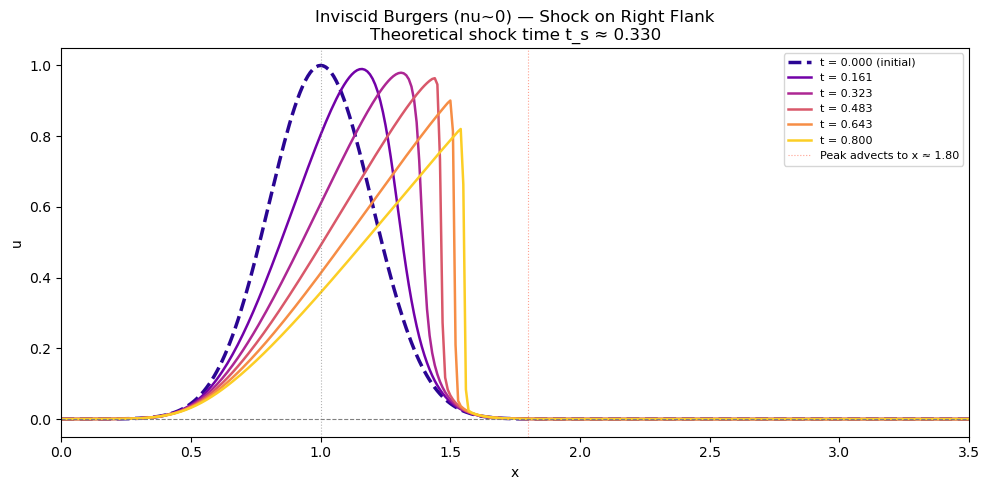

Notice:
  RIGHT flank (leading edge): steepens rapidly → near-vertical shock
  LEFT  flank (trailing edge): broadens and flattens → rarefaction wave
  The pulse also moves rightward because u > 0 everywhere.


In [3]:
def burgers_step(u, dx, dt, nu):
    """One explicit time step of viscous Burgers (general upwind + FTCS diffusion)."""
    u_left  = np.roll(u,  1)
    u_right = np.roll(u, -1)
    conv    = (np.maximum(u, 0) * (u - u_left) +
               np.minimum(u, 0) * (u_right - u)) / dx
    diff    = nu * (u_right - 2*u + u_left) / dx**2
    return u - dt * conv + dt * diff

def burgers_run(u0, dx, nu, T, cfl=0.5, save_count=6):
    """Run Burgers with adaptive dt; return list of (time, solution) snapshots."""
    u          = u0.copy()
    t          = 0.0
    snapshots  = [(0.0, u.copy())]
    save_times = np.linspace(0, T, save_count + 1)[1:]
    next_save  = 0

    while t < T - 1e-12:
        u_max   = max(np.max(np.abs(u)), 1e-8)
        dt_cfl  = cfl * dx / u_max
        dt_diff = 0.4 * dx**2 / nu if nu > 0 else np.inf
        dt      = min(dt_cfl, dt_diff, T - t)
        u       = burgers_step(u, dx, dt, nu)
        t      += dt
        if next_save < len(save_times) and t >= save_times[next_save] - 1e-10:
            snapshots.append((t, u.copy()))
            next_save += 1
    return snapshots

# ── Inviscid: nu = 0 (use tiny nu to avoid division by zero in dt_diff) ───────
nu_inv = 1e-6
T_inv  = 0.8     # well past theoretical shock time ~0.33
snaps  = burgers_run(u0, dx, nu_inv, T_inv, save_count=5)

# theoretical shock time
t_shock_theory = -1.0 / np.min(du0dx[du0dx < 0])
print(f"Theoretical shock time: t_s = {t_shock_theory:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.plasma(np.linspace(0.05, 0.9, len(snaps)))

for (t_s, u_snap), color in zip(snaps, colors):
    lw = 2.5 if t_s == 0 else 1.8
    ls = "--" if t_s == 0 else "-"
    ax.plot(x, u_snap, color=color, lw=lw, ls=ls,
            label=f"t = {t_s:.3f}" + (" (initial)" if t_s == 0 else ""))

ax.axvline(x0,                color="gray",  lw=0.8, ls=":", alpha=0.6)
ax.axvline(x0 + A * T_inv,    color="tomato", lw=0.8, ls=":", alpha=0.6,
           label=f"Peak advects to x ≈ {x0 + A*T_inv:.2f}")
ax.axhline(0, color="gray", lw=0.8, ls="--")

ax.set_title(f"Inviscid Burgers (nu~0) — Shock on Right Flank\n"
             f"Theoretical shock time t_s ≈ {t_shock_theory:.3f}", fontsize=12)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.set_xlim(0, 3.5); ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

print("Notice:")
print("  RIGHT flank (leading edge): steepens rapidly → near-vertical shock")
print("  LEFT  flank (trailing edge): broadens and flattens → rarefaction wave")
print("  The pulse also moves rightward because u > 0 everywhere.")

## 4. Viscous Burgers — Convection vs Diffusion

Now $\nu > 0$. The diffusion term $\nu\,\partial^2 u/\partial x^2$ acts on the shock just like it acted on the Gaussian in Module 1.7:

- At the shock front: **very large curvature** → very large diffusion rate → diffusion strongly opposes steepening
- Away from the shock: gentle curvature → weak diffusion → pulse shape preserved

The **balance** between these two forces sets the steady shock thickness:

$$\delta_{\text{shock}} \sim \frac{\nu}{U} = \frac{1}{Re}$$

Halving $\nu$ halves the shock thickness → you need twice as many grid points to resolve it.

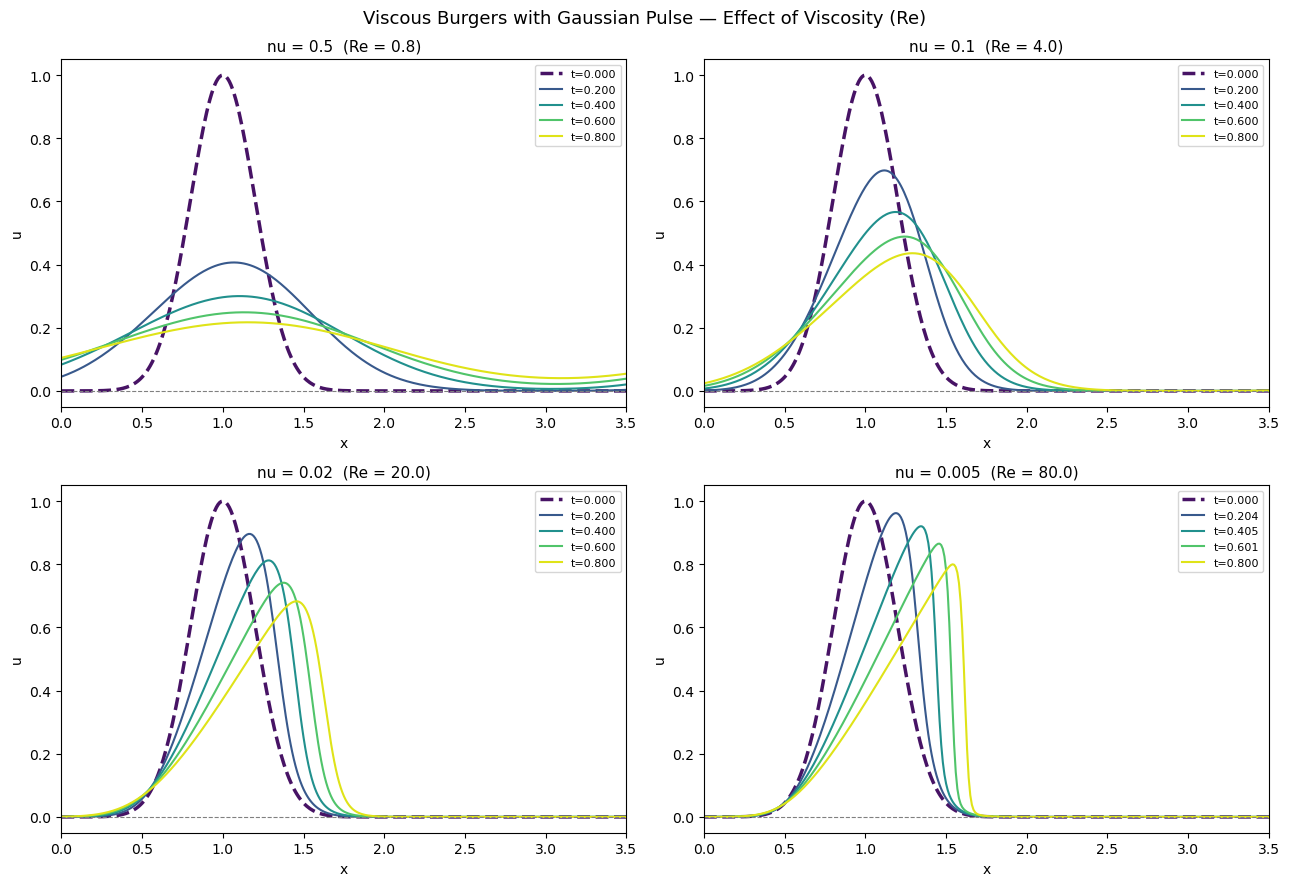

nu=0.5  (low Re):  diffusion dominates — pulse just spreads like pure diffusion
nu=0.1  (mid Re):  mild steepening on right, slight shock visible
nu=0.02 (high Re): clear asymmetry — right flank sharp, left flank broad
nu=0.005(very high Re): sharp shock on right, rarefaction on left


In [4]:
nu_values = [0.5, 0.1, 0.02, 0.005]
T_visc    = 0.8

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, nu in zip(axes.flat, nu_values):
    snaps    = burgers_run(u0, dx, nu, T_visc, save_count=4)
    Re       = A * (2 * sigma) / nu   # Re = U*L/nu,  U=A, L=2*sigma (pulse width)
    colors_v = plt.cm.viridis(np.linspace(0.05, 0.95, len(snaps)))

    for (t_s, u_snap), color in zip(snaps, colors_v):
        lw = 2.5 if t_s == 0 else 1.5
        ls = "--" if t_s == 0 else "-"
        ax.plot(x, u_snap, color=color, lw=lw, ls=ls, label=f"t={t_s:.3f}")

    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(f"nu = {nu}  (Re = {Re:.1f})", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.set_xlim(0.0, 3.5); ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Viscous Burgers with Gaussian Pulse — Effect of Viscosity (Re)", fontsize=13)
plt.tight_layout(); plt.show()

print("nu=0.5  (low Re):  diffusion dominates — pulse just spreads like pure diffusion")
print("nu=0.1  (mid Re):  mild steepening on right, slight shock visible")
print("nu=0.02 (high Re): clear asymmetry — right flank sharp, left flank broad")
print("nu=0.005(very high Re): sharp shock on right, rarefaction on left")

## 5. Convection vs Diffusion — Watching Both Forces Compete

Let's freeze one viscosity value ($\nu = 0.02$) and plot both the **convection** and **diffusion** terms at each time step. This shows exactly which force is winning at each location.

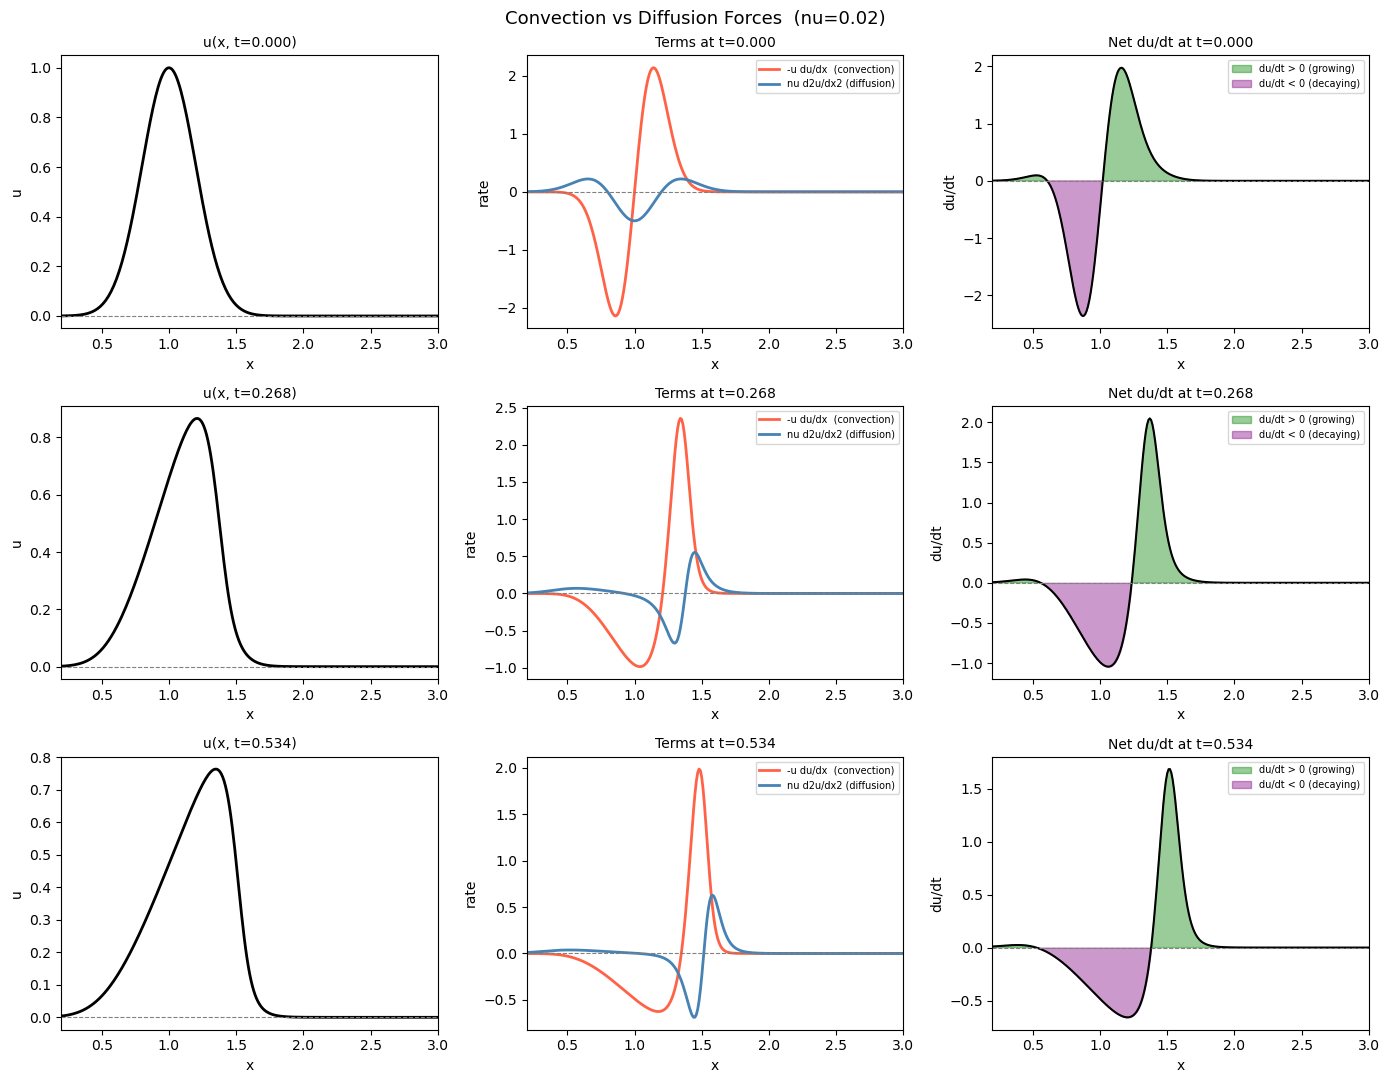

Red line (convection term): steepens the right flank, flattens the left flank
Blue line (diffusion term): always opposes curvature — smooths both flanks
As the shock builds, the blue line grows larger at the front, eventually balancing red.


In [5]:
nu_comp = 0.02
snaps_comp = burgers_run(u0, dx, nu_comp, T_visc, save_count=3)

# Pick 3 snapshots: initial, mid, late
fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for row, (t_s, u_snap) in enumerate(snaps_comp[:3]):
    # Compute convection and diffusion terms from the snapshot
    u_left  = np.roll(u_snap,  1)
    u_right = np.roll(u_snap, -1)

    # Use central difference for display (not for time-stepping)
    conv_term = u_snap * (u_right - u_left) / (2 * dx)          # u * du/dx
    diff_term = nu_comp * (u_right - 2*u_snap + u_left) / dx**2  # nu * d2u/dx2
    net_rate  = -conv_term + diff_term                            # du/dt

    ax_u = axes[row, 0]
    ax_c = axes[row, 1]
    ax_n = axes[row, 2]

    # Column 1: solution
    ax_u.plot(x, u_snap, "k-", lw=2)
    ax_u.axhline(0, color="gray", lw=0.8, ls="--")
    ax_u.set_title(f"u(x, t={t_s:.3f})", fontsize=10)
    ax_u.set_xlabel("x"); ax_u.set_ylabel("u")
    ax_u.set_xlim(0.2, 3.0)

    # Column 2: convection vs diffusion
    ax_c.plot(x, -conv_term, "tomato",    lw=2, label="-u du/dx  (convection)")
    ax_c.plot(x,  diff_term, "steelblue", lw=2, label="nu d2u/dx2 (diffusion)")
    ax_c.axhline(0, color="gray", lw=0.8, ls="--")
    ax_c.set_title(f"Terms at t={t_s:.3f}", fontsize=10)
    ax_c.set_xlabel("x"); ax_c.set_ylabel("rate")
    ax_c.set_xlim(0.2, 3.0); ax_c.legend(fontsize=7)

    # Column 3: net du/dt
    ax_n.fill_between(x, net_rate, where=(net_rate > 0), alpha=0.4, color="green",  label="du/dt > 0 (growing)")
    ax_n.fill_between(x, net_rate, where=(net_rate < 0), alpha=0.4, color="purple", label="du/dt < 0 (decaying)")
    ax_n.plot(x, net_rate, "k-", lw=1.5)
    ax_n.axhline(0, color="gray", lw=0.8, ls="--")
    ax_n.set_title(f"Net du/dt at t={t_s:.3f}", fontsize=10)
    ax_n.set_xlabel("x"); ax_n.set_ylabel("du/dt")
    ax_n.set_xlim(0.2, 3.0); ax_n.legend(fontsize=7)

plt.suptitle(f"Convection vs Diffusion Forces  (nu={nu_comp})", fontsize=13)
plt.tight_layout(); plt.show()

print("Red line (convection term): steepens the right flank, flattens the left flank")
print("Blue line (diffusion term): always opposes curvature — smooths both flanks")
print("As the shock builds, the blue line grows larger at the front, eventually balancing red.")

## 6. What Breaks — Central Differencing for the Convection Term

We learned in Module 1.6 that **central differencing** for advection is unconditionally unstable.
The same is true here for the nonlinear convection term $u\,\partial u/\partial x$.

Central space: $u\,\partial u/\partial x \approx u_i \cdot \frac{u_{i+1} - u_{i-1}}{2\Delta x}$

This has **no preferred direction** — it looks equally left and right regardless of the sign of $u$. For advection-dominated problems this causes exponential growth of odd-even oscillations.

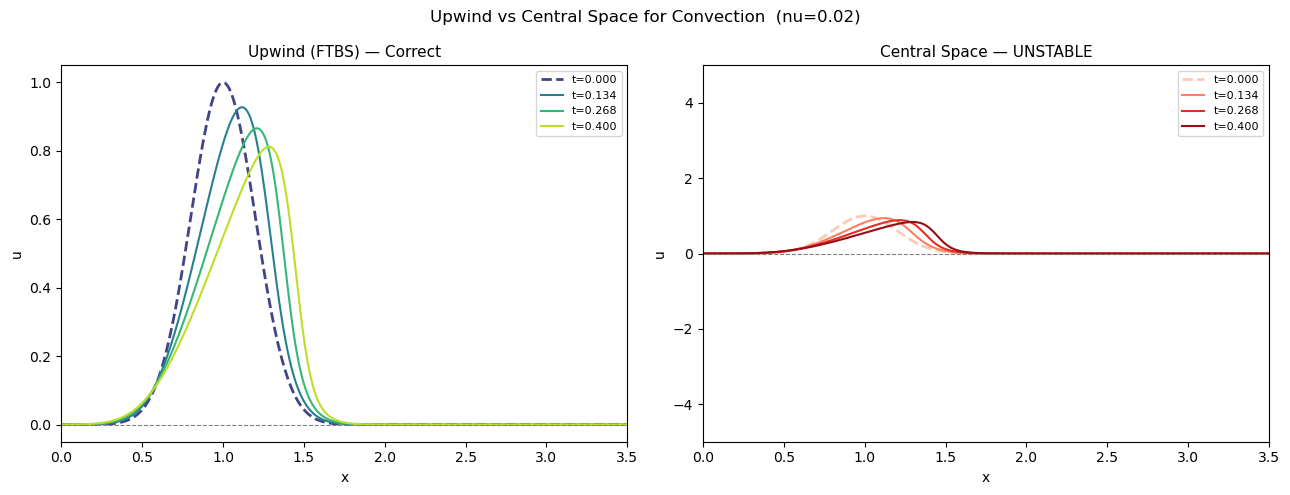

Upwind: looks upstream (left, since u > 0) — stable, physically correct
Central: looks both ways — adds artificial energy to the scheme → instability


In [6]:
def burgers_central(u0, dx, nu, T, cfl=0.5, save_count=4):
    """Burgers with CENTRAL differencing for convection — WRONG, will blow up."""
    u          = u0.copy()
    t          = 0.0
    snapshots  = [(0.0, u.copy())]
    save_times = np.linspace(0, T, save_count + 1)[1:]
    next_save  = 0

    while t < T - 1e-12:
        u_max   = max(np.max(np.abs(u)), 1e-8)
        dt_cfl  = cfl * dx / u_max
        dt_diff = 0.4 * dx**2 / nu if nu > 0 else np.inf
        dt      = min(dt_cfl, dt_diff, T - t)

        u_left  = np.roll(u,  1)
        u_right = np.roll(u, -1)

        # CENTRAL differencing for convection — looks both ways, ignores wave direction
        conv_central = u * (u_right - u_left) / (2 * dx)
        diff         = nu * (u_right - 2*u + u_left) / dx**2

        u = u - dt * conv_central + dt * diff
        t += dt

        if next_save < len(save_times) and t >= save_times[next_save] - 1e-10:
            snapshots.append((t, u.copy()))
            next_save += 1

        # Safety: stop if solution explodes
        if np.max(np.abs(u)) > 100:
            snapshots.append((t, u.copy()))
            print(f"  CENTRAL scheme exploded at t = {t:.4f}!")
            break
    return snapshots

# ── Side-by-side: upwind (correct) vs central (wrong) ────────────────────────
nu_test = 0.02
T_test  = 0.4

snaps_upwind  = burgers_run    (u0, dx, nu_test, T_test, save_count=3)
snaps_central = burgers_central(u0, dx, nu_test, T_test, save_count=3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, snaps, title, cmap in zip(
    axes,
    [snaps_upwind, snaps_central],
    ["Upwind (FTBS) — Correct", "Central Space — UNSTABLE"],
    [plt.cm.viridis, plt.cm.Reds]
):
    colors_p = cmap(np.linspace(0.2, 0.9, len(snaps)))
    for (t_s, u_snap), color in zip(snaps, colors_p):
        lw = 2 if t_s == 0 else 1.5
        ls = "--" if t_s == 0 else "-"
        ax.plot(x, u_snap, color=color, lw=lw, ls=ls, label=f"t={t_s:.3f}")
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.set_xlim(0.0, 3.5)
    if "UNSTABLE" in title:
        ax.set_ylim(-5, 5)
    ax.legend(fontsize=8)

plt.suptitle(f"Upwind vs Central Space for Convection  (nu={nu_test})", fontsize=12)
plt.tight_layout(); plt.show()

print("Upwind: looks upstream (left, since u > 0) — stable, physically correct")
print("Central: looks both ways — adds artificial energy to the scheme → instability")

## 7. Summary — Everything Burgers Teaches You

| Concept | Burgers (Gaussian) | Navier-Stokes |
|---------|-------------------|---------------|
| Nonlinear convection | Right flank steepens → shock | Boundary layers, flow separation |
| Rarefaction | Left flank broadens | Wakes behind objects |
| Shock thickness | $\delta \sim \nu/U = 1/Re$ | Boundary layer thickness $\sim 1/\sqrt{Re}$ |
| Upwind required | Yes — central blows up | Yes — for the $(\mathbf{u}\cdot\nabla)\mathbf{u}$ term |
| Two stability limits | CFL ≤ 1 AND r ≤ 0.5 | Same in explicit NS solvers |
| Adaptive dt | Needed at high Re | Needed in unsteady NS |

### The physical picture to remember

```
Low Re  (high nu):   Diffusion wins    → smooth, spreading pulse
High Re (low nu):    Convection wins   → sharp shock on right flank
                                          rarefaction on left flank
Infinite Re (nu=0):  Shock forms at t_s = -1 / min(du0/dx)
```

### Connection to Navier-Stokes

The full 1D Navier-Stokes momentum equation for incompressible flow looks like:

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu\frac{\partial^2 u}{\partial x^2}$$

It's Burgers' equation + a pressure gradient term. Everything you learned here applies directly in Module 2.